In [14]:
import pandas as pd
from pathlib import Path

CSV_PATH = Path('../coin-selection-c-master/simulation/users/')

csvs = list(CSV_PATH.iterdir())

def balance_df_from_csv(csv):
    lines = None
    with open(csv) as inp:
        lines = inp.readlines()
    balance = 0
    balances = []

    for line in lines[1:]:
        op, amount, time = line.split(",")
        op, amount, time = int(op), int(amount), int(time)
        if op == 0:
            balance -= amount
        elif op == 1:
            balance += amount
        else:
            print("unknown op:", op)
        balances.append({"Time": time, "Balance": balance, "FileName": csv})
    return pd.DataFrame(balances)

In [23]:
dfs = pd.concat(balance_df_from_csv(csv) for csv in csvs)
print(dfs)

          Time    Balance                                           FileName
0            0          0  ../coin-selection-c-master/simulation/users/us...
1        86400          0  ../coin-selection-c-master/simulation/users/us...
2       172800          0  ../coin-selection-c-master/simulation/users/us...
3       259200          0  ../coin-selection-c-master/simulation/users/us...
4       259200     858729  ../coin-selection-c-master/simulation/users/us...
...        ...        ...                                                ...
1472  92966400  445927200  ../coin-selection-c-master/simulation/users/us...
1473  92966400  445904918  ../coin-selection-c-master/simulation/users/us...
1474  93052800  445887776  ../coin-selection-c-master/simulation/users/us...
1475  93139200  445863139  ../coin-selection-c-master/simulation/users/us...
1476  93225600  445839186  ../coin-selection-c-master/simulation/users/us...

[17724 rows x 3 columns]


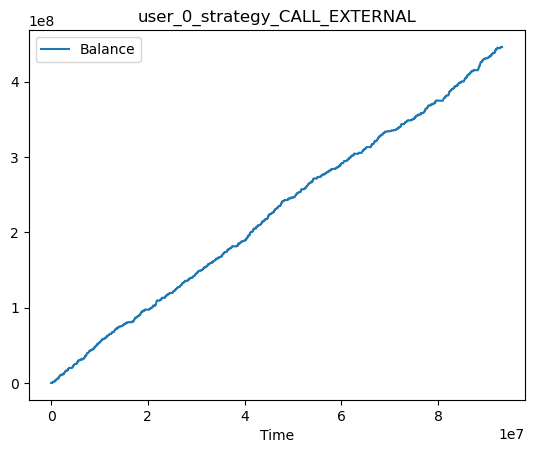

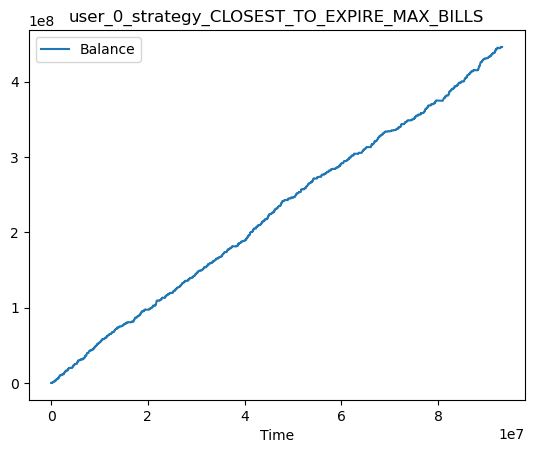

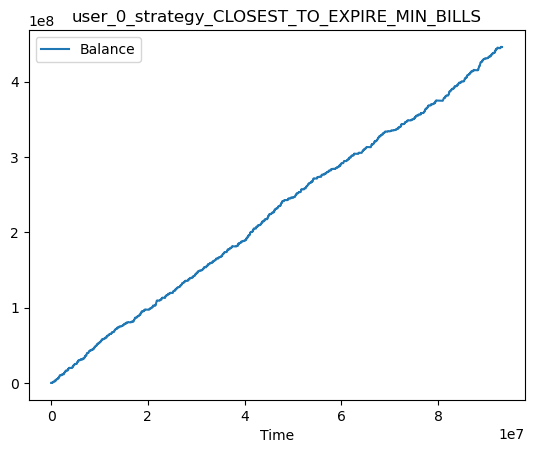

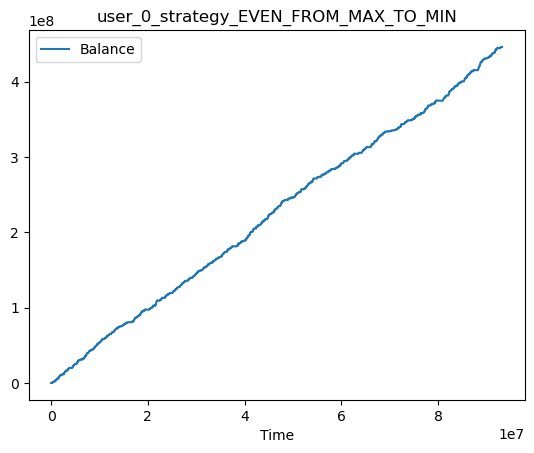

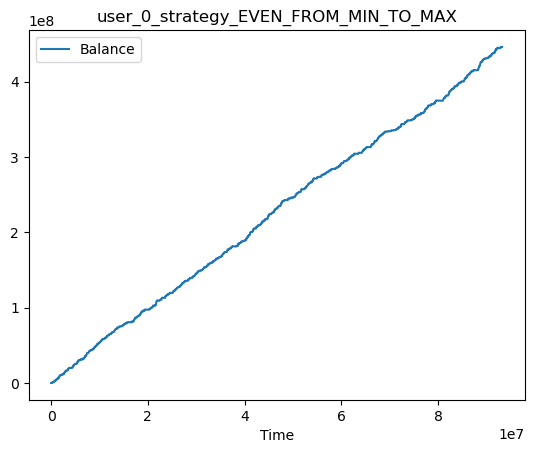

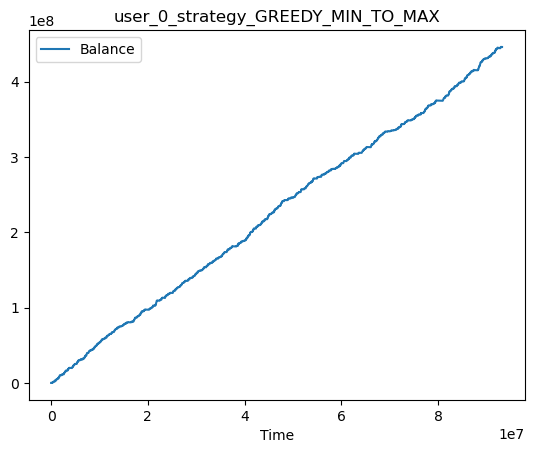

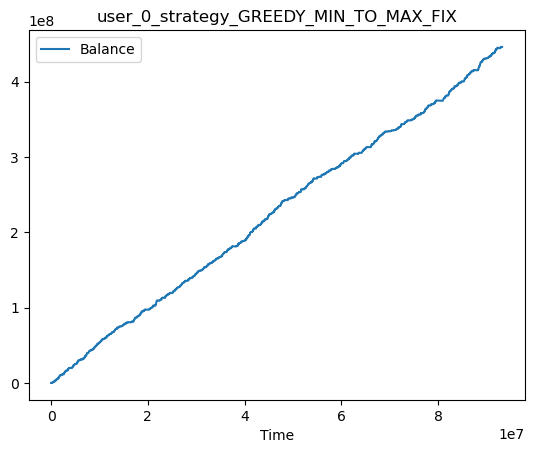

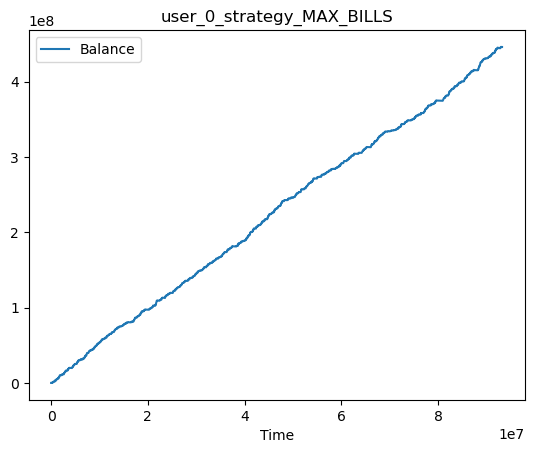

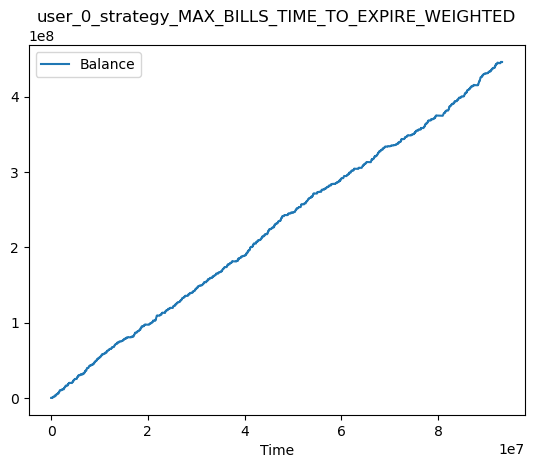

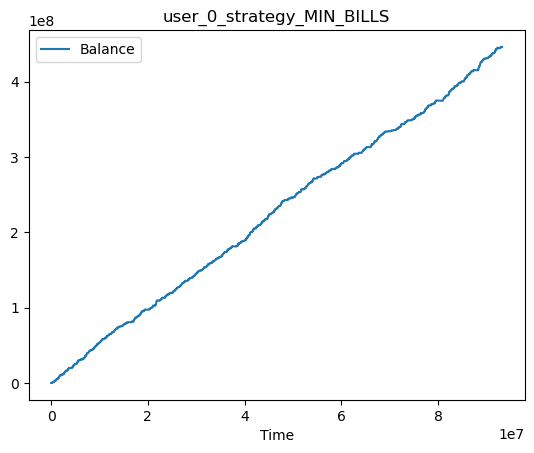

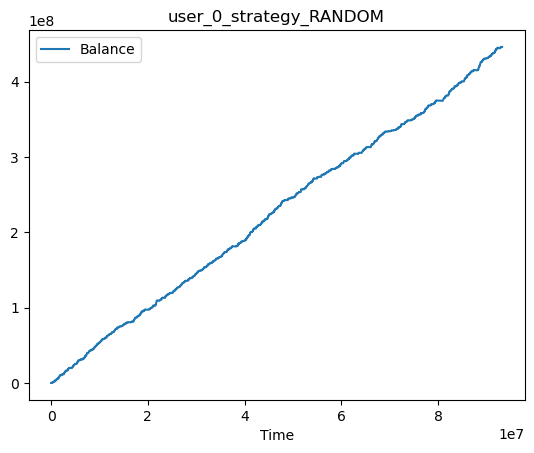

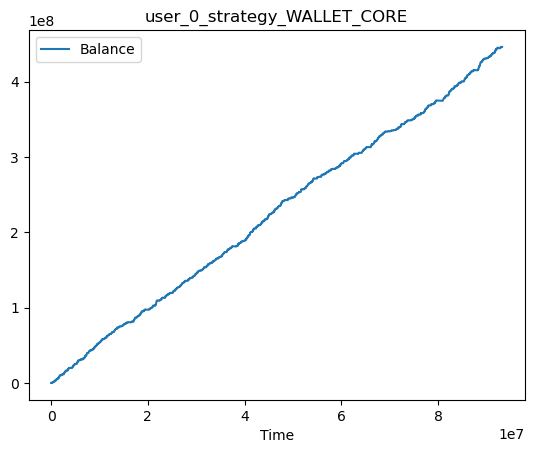

In [22]:
for file_name, user_df in dfs.groupby('FileName'):
    name = file_name.name.split(".")[0]
    name = name.removeprefix("coins_user_0_strategy_")
    ax = user_df.plot.line(x="Time", y="Balance", title=name)
    fig = ax.get_figure()
    fig.savefig(f"pictures/area-{name}", dpi=300)